In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset
import numpy as np
import copy
import time
import pandas as pd
import torch.nn.init as init
import csv
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [4]:
# Set random seeds for reproducibility
torch.manual_seed(123)
np.random.seed(123)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(123)

# Check and initialize GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")    
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

class BinaryClassifier_all(nn.Module):
    def __init__(self, input_dim=256):
        """
        Binary classifier that distinguishes between:
         - ENCRYPTED (label 1)
         - COMPRESSED (label 0; macro-label combining 14 formats)
        Architecture:
          FC: 256 -> 256, SELU
          FC: 256 -> 256, SELU
          FC: 256 -> 256, SELU
          FC: 256 -> 128, SELU
          FC: 128 -> 2, LogSoftmax
        We use LeCun normal initialization on the Linear layers.
        """
        super(BinaryClassifier_all, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 256)
        self.fc4 = nn.Linear(256, 128)
        self.fc5 = nn.Linear(128, 2)
        
        self.selu = nn.SELU()
        self.log_softmax = nn.LogSoftmax(dim=1)
        self._initialize_weights()
        
    def _initialize_weights(self):
        for layer in self.modules():
            if isinstance(layer, torch.nn.Linear):
                # LeCun normal initialization: Variance = 1 / fan-in
                init.normal_(layer.weight, mean=0.0, std=(1.0 / layer.in_features) ** 0.5)
                if layer.bias is not None:
                    init.zeros_(layer.bias)
                    
    def forward(self, x):
        # x shape: (batch_size, 256)
        x = self.selu(self.fc1(x))
        x = self.selu(self.fc2(x))
        x = self.selu(self.fc3(x))
        x = self.selu(self.fc4(x))
        x = self.fc5(x)
        return self.log_softmax(x)  # log-probabilities
    
class CustomDataset(Dataset):
    def __init__(self, data0, data1, transform=None):
        """
        read csv files of 2 class. it is assumed that they dont have headers and labels 
        and all features are numerical
        """
        super(CustomDataset, self).__init__()
        # data0 = pd.read_csv(class0_csv, header= None)
        # data1 = pd.read_csv(class1_csv, header = None)
        data0["label"] = 0
        data1["label"] = 1
        data = pd.concat([data0, data1], ignore_index=True)
        data = data.sample(frac=1, random_state=123)
        
        self.X = data.drop(columns=["label"]).values
        self.y = data["label"].values
        self.transform = transform
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, index):
        X = self.X[index]
        y = self.y[index]
        
        if self.transform:
            X = self.transform(X)
        
        # No need to specify device here, will be moved to appropriate device in training loop
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

class f_min_max:
    def __init__(self, input_length=4096):
        self.input_length = input_length
        
    def __call__(self, x):
        # Check if input is a single sample or a batch
        if isinstance(x, np.ndarray) and x.ndim == 1:
            # Single sample case
            hist = np.bincount(x.astype(int), minlength=256)
            # Normalize histogram
            hist = (hist / self.input_length) * 2.0
            return hist
        else:
            # Batch case
            all_hist = []
            for row in x:
                # Convert to integers if needed
                row_int = row.astype(int)
                # GPU-safe histogram: use bincount
                hist = np.bincount(row_int, minlength=256)
                # Normalize: divide by input length and scale to match original
                hist = (hist / self.input_length) * 2.0
                all_hist.append(hist)
            return np.array(all_hist)
        
def train_model(model, train_dataloader, val_dataloader, device, criterion, optimizer, num_epochs):
    best_val_acc = 0.0
    best_model_state = None
    
    model.train()
    print("Training started...")
    print(f"Model is on device: {next(model.parameters()).device}")
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Training phase
        model.train()
        for batch_idx, (features, labels) in enumerate(train_dataloader):
            # Move data to the same device as model
            features = features.to(device)
            labels = labels.to(device)
            
            # Check device placement for debugging
            # if batch_idx == 0 and epoch == 0:
                # print(f"Data device: {features.device}, Model device: {next(model.parameters()).device}")
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        train_loss = running_loss / len(train_dataloader)
        train_acc = correct / total
        
        # Validation phase
        val_acc = evaluate_model(model, val_dataloader, device)
        
        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs}")
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
            # Save model checkpoint
            checkpoint_path = f'model_epoch_{epoch+1}.pth'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': train_loss,
                'val_acc': val_acc
            }, checkpoint_path)
            
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"New best model saved with validation accuracy: {best_val_acc:.4f}")
            torch.save(best_model_state, 'best_model.pth')
    
    print(f"Training completed. Best validation accuracy: {best_val_acc:.4f}")
    return best_val_acc, best_model_state
        
def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0 
    total = 0
    
    with torch.no_grad():
        for features, labels in dataloader:
            # Move data to the same device as model
            features = features.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(features)
            
            # Get predictions
            _, predictions = torch.max(outputs, dim=1)
            
            # Update statistics
            total += labels.size(0)
            correct += (predictions == labels).sum().item()
            
    # Return accuracy
    return correct / total

def plot_confusion_matrix_from_dataloader(model, dataloader, device, class_names=None, 
                                        figsize=(10, 8), cmap='Blues', normalize=False, 
                                        title='Confusion Matrix', save_path=None,
                                        num_workers=0):  # Set num_workers to 0 to avoid pickling errors
    """
    Get predictions from dataloader and plot confusion matrix with annotations.
    
    Args:
        model: PyTorch model
        dataloader: PyTorch DataLoader
        device: Device to run the model on (cuda or cpu)
        class_names: List of class names, defaults to ['COMPRESSED', 'ENCRYPTED']
        figsize: Figure size (width, height)
        cmap: Colormap for the heatmap
        normalize: Whether to normalize the confusion matrix
        title: Title for the plot
        save_path: Path to save the confusion matrix image, if None, won't save
        num_workers: Number of workers for DataLoader (use 0 to avoid pickling errors)
        
    Returns:
        Figure object and metrics dictionary
    """
    if class_names is None:
        class_names = ['UNENCRYPTED', 'ENCRYPTED']
    
    # Make sure dataloader has num_workers=0 to avoid pickling errors
    # We'll recreate it if needed
    if hasattr(dataloader, 'num_workers') and dataloader.num_workers > 0:
        # Create a new dataloader with num_workers=0
        new_dataloader = torch.utils.data.DataLoader(
            dataloader.dataset,
            batch_size=dataloader.batch_size,
            shuffle=False,  # Keep order consistent
            num_workers=0,
            pin_memory=False
        )
        dataloader = new_dataloader
    
    # Get predictions
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for features, labels in dataloader:
            # Move data to the same device as model
            features = features.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(features)
            
            # Get predictions
            _, predictions = torch.max(outputs, dim=1)
            
            # Append to lists
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Normalize if required
    if normalize:
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(cm_norm*100, annot=True, fmt='.2f', xticklabels=class_names, 
                    yticklabels=class_names, cmap=cmap, ax=ax)
        title = f'Normalized {title}'
    else:
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, 
                    yticklabels=class_names, cmap=cmap, ax=ax)
    
    # Add labels and title
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Create metrics dictionary
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }
    
    # Add metrics text
    metrics_text = (f"Accuracy: {accuracy:.4f}\n"
                   f"Precision: {precision:.4f}\n"
                   f"Recall: {recall:.4f}\n"
                   f"F1-score: {f1:.4f}")
    
    # Add text box with metrics
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    plt.figtext(0.15, 0.05, metrics_text, fontsize=12, 
                bbox=props, horizontalalignment='left')
    
    plt.tight_layout()
    
    # Save figure if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, metrics


Using device: cuda
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3070 Laptop GPU


In [ ]:


# Main execution
if __name__ == "__main__":
    try:
        # File paths - consider using relative paths or environment variables
        data0_path = "G:\dataset_mnp\mnp_fragment\\all_unenc(50_50).csv"
        data1_path = "G:\dataset_mnp\mnp_fragment\\all_encrar.csv"

        print(f"Loading data from {data0_path} and {data1_path}")
        data0 = pd.read_csv(data0_path, header=None)
        data1 = pd.read_csv(data1_path, header=None)
        
        # Create dataset
        dataset = CustomDataset(data0, data1, f_min_max())
        print(f"Dataset created with {len(dataset)} samples")
        
        # Split dataset
        total_samples = len(dataset)
        train_size = int(0.85 * total_samples)
        val_size = int(0.05 * total_samples)
        test_size = total_samples - train_size - val_size
        
        train_dataset, val_dataset, test_dataset = random_split(
            dataset, [train_size, val_size, test_size]
        )
        
        print(f"Dataset split: Train={train_size}, Val={val_size}, Test={test_size}")
        
        # Create data loaders
        batch_size = 64
        train_dataloader = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True
        )
        val_dataloader = DataLoader(
            val_dataset, batch_size=batch_size, num_workers=4, pin_memory=True
        )
        test_dataloader = DataLoader(
            test_dataset, batch_size=batch_size, num_workers=4, pin_memory=True
        )
        
        # Initialize model
        model = BinaryClassifier_all().to(device)
        
        # Training parameters
        criterion = nn.NLLLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.00001)
        num_epochs = 100
        
        
    except Exception as e:
        print(f"An error occurred: {e}")

In [ ]:
if __name__ == "__main__":
        #train_model
        final_val_acc, best_model_state = train_model(
            model, train_dataloader, val_dataloader, device, criterion, optimizer, num_epochs
        )
        
        # Evaluate on test set
        model.load_state_dict(best_model_state)
        test_acc = evaluate_model(model, test_dataloader, device)
        print(f"Final test accuracy: {test_acc:.4f}")

In [2]:
if __name__ == "__main__":
    #plotting confusion matrix on test
    model = BinaryClassifier_all().to(device)
    state_dict = torch.load(".//model_epoch_100.pth")
    model.load_state_dict(state_dict['model_state_dict'])
    # state_dict = torch.load("./best_model.pth")
    # model.load_state_dict(state_dict)
    # fig, met = plot_confusion_matrix_from_dataloader(model, test_dataloader, device, normalize=True )
    # fig.show()


NameError: name 'BinaryClassifier_all' is not defined

C:\Users\ali_h.ALIRA\AppData\Local\Temp\ipykernel_18340\149571923.py:274: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
C:\Users\ali_h.ALIRA\AppData\Local\Temp\ipykernel_18340\3900020346.py:21: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


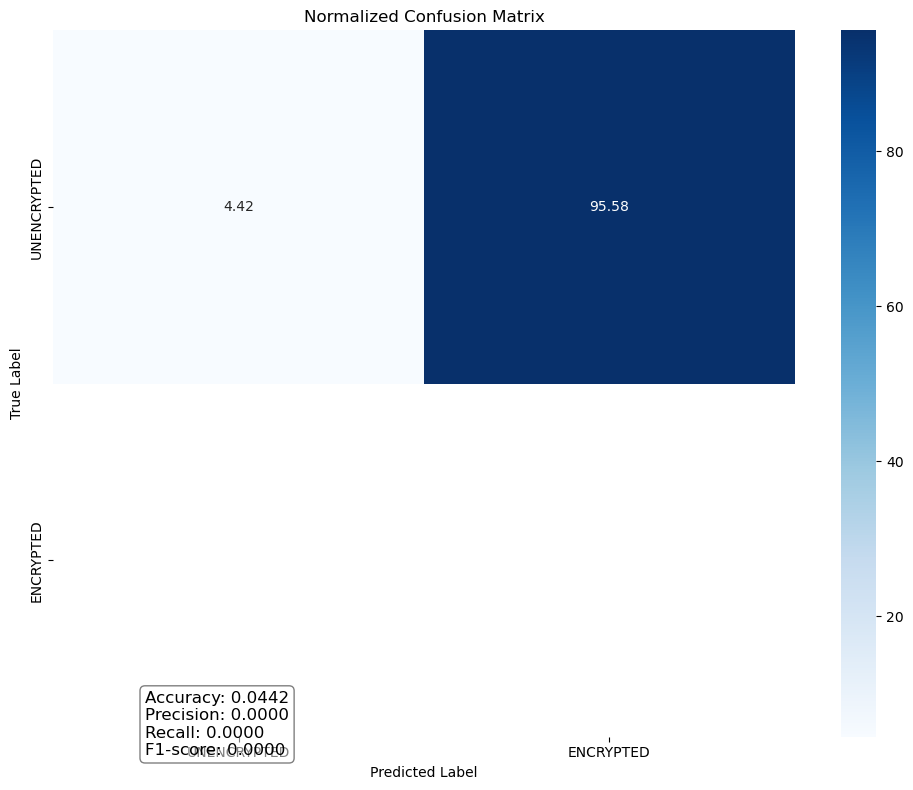

In [6]:
if __name__ == "__main__":
    #plotting confusion matrix for new test 
    external_csv_filepath = "D:\\DATASETS\\dataset_itctext + mnp\\fragments\\64117\\all_encrar.csv"
    #external_csv_filepath ="G:\dataset_mnp\mnp_fragment\\all_encrar.csv"
    x_new_test = np.loadtxt(external_csv_filepath, delimiter=',', dtype=np.uint8)
    #x_new_test = x_new_test[:10000, :]
    y_new_test = x_new_test.shape[0] * [0]
    f_min_max_1 = f_min_max()
    x_new_test = f_min_max_1(x_new_test)
    BATCH_SIZE = 32
    x_new_test = torch.tensor(x_new_test, dtype=torch.float32)
    y_new_test = torch.tensor(y_new_test, dtype=torch.long)
    new_test_dataset = TensorDataset(x_new_test, y_new_test)
    new_test_loader = DataLoader(new_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    
    model = BinaryClassifier_all().to(device)
    state_dict = torch.load("./best_model.pth")
    model.load_state_dict(state_dict)
    fig, met = plot_confusion_matrix_from_dataloader(model, new_test_loader, device, normalize=True )
    fig.show()